# Разрез графа. Матрица Лапласа.

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Макрушин С.В. "Лекция 5: Выявление сообществ в сетях 2. Спектральные методы"
* Документация:
    * https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.cuts.cut_size.html
    * https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.cuts.normalized_cut_size.html
    * https://networkx.org/documentation/stable/reference/generated/networkx.linalg.laplacianmatrix.laplacian_matrix.html
    * https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.cuts.volume.html
    * https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.components.connected_components.html
    * https://numpy.org/doc/stable/reference/generated/numpy.linalg.eig.html

## Вопросы для совместного обсуждения

1\. Обсудите понятия разреза графа и матрицы Лапласа.

## Задачи для самостоятельного решения

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from typing import List, Set, Tuple

np.set_printoptions(precision=4, suppress=True)

<p class="task" id="1"></p>

1\. Задан граф `G`. Определите два разреза:

*  $C^{(1)}=(N_1^{(1)}, N_2^{(1)})$, $N_1^{(1)} = \{0, 1, 2, 3, 4\}$, $N_2^{(1)} = \{5, 6, 7, 8, 9\} $
*  $C^{(2)}=(N_1^{(2)}, N_2^{(2)})$, $N_1^{(2)} = \{0, 1, 2, 3, 4, 5, 6, 7, 8\}$, $N_2^{(2)} = \{9\} $

Для каждого из разрезов вычислите величину $Q^{(k)}$ двумя способами: явным образом просмотрев все ребра и при помощи функции из пакета `networkx`. Выведите величины разрезов на экран.

$$Q^{(k)}=cut(N_1^{(k)},N_2^{(k)})=\sum_{i \in N_1^{(k)}, j \in N_2^{(k)}} l_{ij}$$

- [ ] Проверено на семинаре

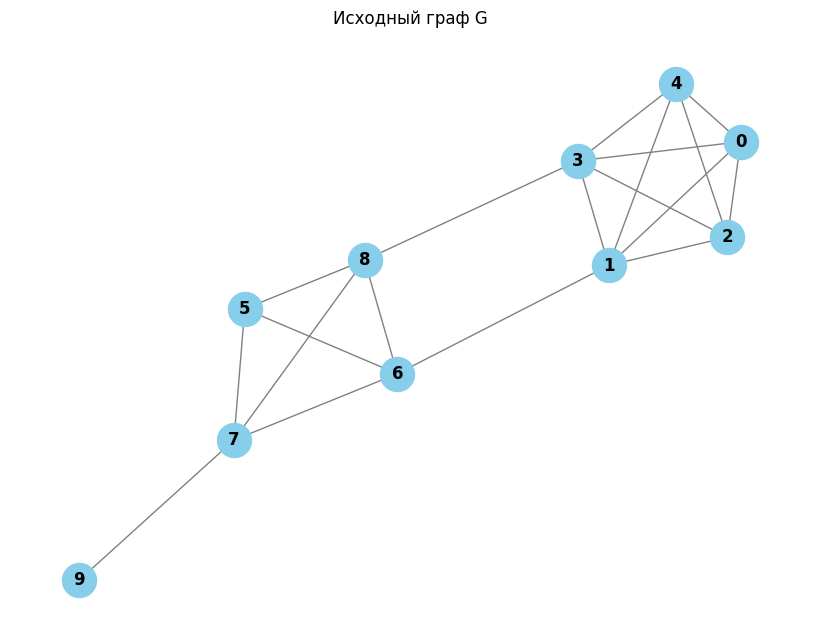

In [2]:
def create_graph() -> nx.Graph:
    """Создает граф согласно условиям задачи."""
    G = nx.Graph()
    G.add_edges_from(combinations(range(5), 2))
    G.add_edges_from(combinations(range(5, 9), 2))
    G.add_edges_from([(8, 3), (6, 1), (7, 9)])
    return G

G = create_graph()

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=30)
nx.draw(G, pos=pos, with_labels=True, node_color='skyblue', node_size=600, font_weight='bold', edge_color='gray')
plt.title("Исходный граф G")
plt.show()

In [3]:
N1_1= {0, 1, 2, 3, 4}
N2_1= {5, 6, 7, 8, 9}

N1_2= {0, 1, 2, 3, 4, 5, 6, 7, 8}
N2_2= {9}

def manual_cut_size(G: nx.Graph, set1: Set[int], set2: Set[int]) -> int:
    cut_weight = 0
    for u, v in G.edges():
        if (u in set1 and v in set2) or (v in set1 and u in set2):
            cut_weight += 1
    return cut_weight

q1_manual = manual_cut_size(G, N1_1, N2_1)
q1_nx = nx.cut_size(G, N1_1, N2_1)

q2_manual = manual_cut_size(G, N1_2, N2_2)
q2_nx = nx.cut_size(G, N1_2, N2_2)

print(f"Разрез C(1) [ручной подсчет]: {q1_manual}")
print(f"Разрез C(1) [NetworkX]:      {q1_nx}")
print(f"Разрез C(2) [ручной подсчет]: {q2_manual}")
print(f"Разрез C(2) [NetworkX]:      {q2_nx}")

assert q1_manual == q1_nx, "Ошибка в логике ручного подсчета C1"
assert q2_manual == q2_nx, "Ошибка в логике ручного подсчета C2"

Разрез C(1) [ручной подсчет]: 2
Разрез C(1) [NetworkX]:      2
Разрез C(2) [ручной подсчет]: 1
Разрез C(2) [NetworkX]:      1


<p class="task" id="2"></p>

2\. Для разрезов из предыдущего задания вычислите 

$$ Vol(N_t^{(k)}) = \sum_{i \in N_t^{(k)}, j \in N} l_{ij}=\sum_{i \in N_t^{(k)}} k_{i}, t=1,2 $$

$$Q_{normalized}^{(k)}=\frac{cut(N_1^{(k)},N_2^{(k)})}{Vol(N_1^{(k)})}+\frac{cut(N_1^{(k)},N_2^{(k)})}{Vol(N_2^{(k)})}$$
и
$$Q_{quotient}^{(k)}=\frac{cut(N_1^{(k)},N_2^{(k)})}{\min(Vol(N_1^{(k)}),Vol(N_2^{(k)}))}$$

Для каждого разреза выведите четыре величины $Vol(N_1^{(k)})$, $Vol(N_2^{(k)})$, $Q_{normalized}^{(k)}$ и $Q_{quotient}^{(k)}$ на экран.
- [ ] Проверено на семинаре

In [6]:
def calculate_metrics(G: nx.Graph, N1: Set[int], N2: Set[int], cut_name: str):

    vol_n1 = sum(dict(G.degree(N1)).values())
    vol_n2 = sum(dict(G.degree(N2)).values())
    
    cut_val = nx.cut_size(G, N1, N2)
    
    q_norm = (cut_val / vol_n1) + (cut_val / vol_n2)
    q_quotient = cut_val / min(vol_n1, vol_n2)
    
    print(f"Метрики для {cut_name}")
    print(f"Vol(N1) = {vol_n1}\nVol(N2) = {vol_n2}")
    print(f"Q_normalized = {q_norm:.4f}")
    print(f"Q_quotient   = {q_quotient:.4f}\n")

calculate_metrics(G, N1_1, N2_1, "C(1)")
calculate_metrics(G, N1_2, N2_2, "C(2)")

Метрики для C(1)
Vol(N1) = 22
Vol(N2) = 16
Q_normalized = 0.2159
Q_quotient   = 0.1250

Метрики для C(2)
Vol(N1) = 37
Vol(N2) = 1
Q_normalized = 1.0270
Q_quotient   = 1.0000



<p class="task" id="3"></p>

3\. Для графа `G` из задания 1 вычислите матрицу Лапласа двумя способами:
* по формуле $\mathbf{L}=\mathbf{D}-\mathbf{A}$;
* используя готовую функцию из `networkx`.

Выведите полученные матрицы на экран и покажите, что они равны.

- [ ] Проверено на семинаре

In [8]:
A = nx.adjacency_matrix(G).toarray()

degrees =[deg for node, deg in G.degree()]
D = np.diag(degrees)

L_manual = D - A

L_nx = nx.laplacian_matrix(G).toarray()

are_equal = np.allclose(L_manual, L_nx)

print(f"Матрицы совпадают: {are_equal}")
print("\nМатрица Лапласа (L):")
print(L_manual)

Матрицы совпадают: True

Матрица Лапласа (L):
[[ 4 -1 -1 -1 -1  0  0  0  0  0]
 [-1  5 -1 -1 -1  0 -1  0  0  0]
 [-1 -1  4 -1 -1  0  0  0  0  0]
 [-1 -1 -1  5 -1  0  0  0 -1  0]
 [-1 -1 -1 -1  4  0  0  0  0  0]
 [ 0  0  0  0  0  3 -1 -1 -1  0]
 [ 0 -1  0  0  0 -1  4 -1 -1  0]
 [ 0  0  0  0  0 -1 -1  4 -1 -1]
 [ 0  0  0 -1  0 -1 -1 -1  4  0]
 [ 0  0  0  0  0  0  0 -1  0  1]]


<p class="task" id="4"></p>

4\. Для каждого из разрезов первого задания вычислите величины $Q^{(k)}$, воспользовавшись матрицей Лапласа.

- [ ] Проверено на семинаре

In [ ]:
def cut_size_via_laplacian(L: np.ndarray, N1: Set[int], num_nodes: int) -> float:
    x = np.zeros((num_nodes, 1))
    
    for node in N1:
        x[node] = 1
    cut_size = (x.T @ L @ x)[0, 0]
    
    return int(cut_size)

num_nodes = G.number_of_nodes()

q1_laplacian = cut_size_via_laplacian(L_manual, N1_1, num_nodes)
q2_laplacian = cut_size_via_laplacian(L_manual, N1_2, num_nodes)

print(f"Разрез C(1) через Лапласиан: {q1_laplacian}")
print(f"Разрез C(2) через Лапласиан: {q2_laplacian}")

Разрез C(1) через Лапласиан: 2
Разрез C(2) через Лапласиан: 1


<p class="task" id="5"></p>

5\. Найдите собственные значения и собственные векторы матрицы Лапласа. Выведите на экран кратность нулевого собственного значения матрицы Лапласа. Найдите и выведите на экран количество компонент связности в графе `G`. 

Создайте копию графа `G` с удаленными ребрами в соответствии с разрезом $C^{(1)}$. Повторите решение задачи для получившегося несвязного графа.

- [ ] Проверено на семинаре

In [11]:
def analyze_laplacian_spectrum(graph: nx.Graph, graph_name: str):
    """Анализирует спектр графа (вычисляет eigenvalues и количество компонент)."""
    L = nx.laplacian_matrix(graph).toarray() # [N, N]
    eigenvalues, eigenvectors = np.linalg.eigh(L)
    
    eps = 1e-10
    zero_eig_count = np.sum(eigenvalues < eps)
    
    nx_components = nx.number_connected_components(graph)
    
    print(f"Анализ для {graph_name}")
    print(f"Первые 5 собственных значений: {eigenvalues[:5]}") 
    print(f"Кратность нулевого собственного значения: {zero_eig_count}")
    print(f"Количество компонент связности (NetworkX): {nx_components}\n")
    
    assert zero_eig_count == nx_components, "Теорема не выполняется (возможно проблема с точностью порога eps)"


analyze_laplacian_spectrum(G, "Исходного графа G")

G_disconnected = G.copy()

edges_to_remove =[]
for u, v in G.edges():
    if (u in N1_1 and v in N2_1) or (v in N1_1 and u in N2_1):
        edges_to_remove.append((u, v))


G_disconnected.remove_edges_from(edges_to_remove)

analyze_laplacian_spectrum(G_disconnected, "Несвязного графа (после удаления разреза C(1))")

Анализ для Исходного графа G
Первые 5 собственных значений: [-0.      0.5041  1.2496  4.2037  4.382 ]
Кратность нулевого собственного значения: 1
Количество компонент связности (NetworkX): 1

Анализ для Несвязного графа (после удаления разреза C(1))
Первые 5 собственных значений: [-0. -0.  1.  4.  4.]
Кратность нулевого собственного значения: 2
Количество компонент связности (NetworkX): 2



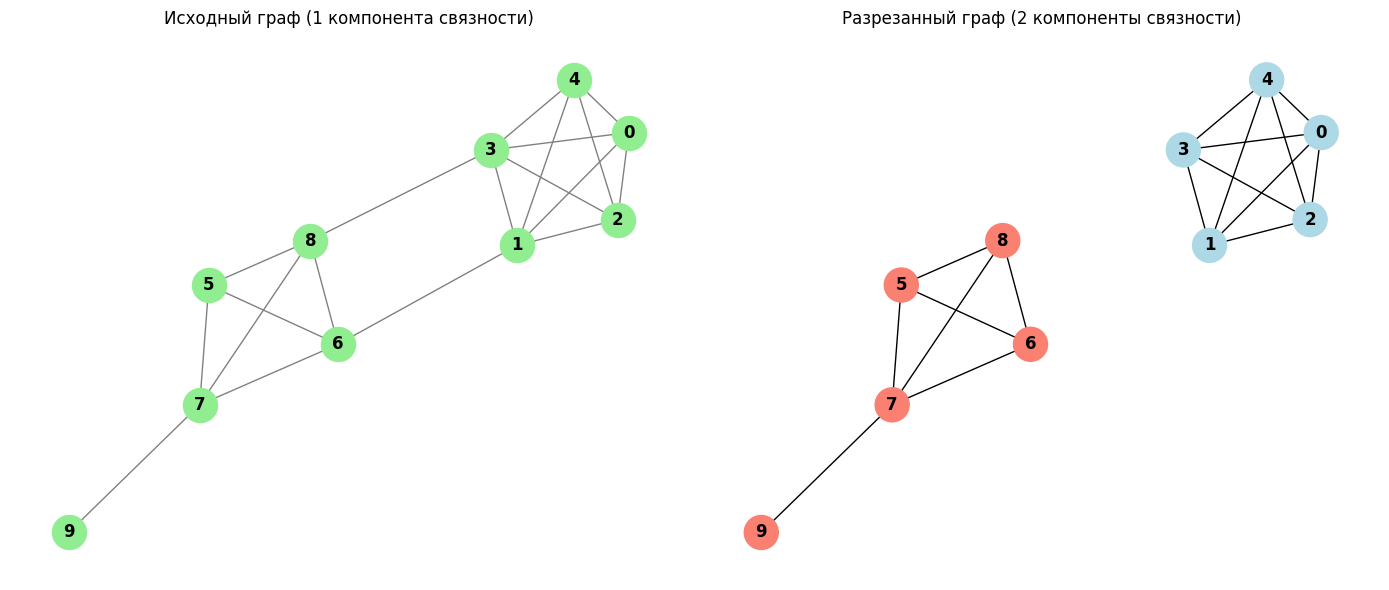

In [12]:
def plot_graphs_comparison(g_original: nx.Graph, g_disconnected: nx.Graph):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    pos = nx.spring_layout(g_original, seed=30)
    
    nx.draw(g_original, pos, ax=axes[0], with_labels=True, 
            node_color='lightgreen', node_size=600, font_weight='bold', edge_color='gray')
    axes[0].set_title("Исходный граф (1 компонента связности)")

    color_map =['lightblue' if node in N1_1 else 'salmon' for node in g_disconnected.nodes()]
    
    nx.draw(g_disconnected, pos, ax=axes[1], with_labels=True, 
            node_color=color_map, node_size=600, font_weight='bold', edge_color='black')
    axes[1].set_title("Разрезанный граф (2 компоненты связности)")
    
    plt.tight_layout()
    plt.show()

plot_graphs_comparison(G, G_disconnected)